In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [86]:
df=pd.read_csv('spam.csv')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [87]:
df.shape

(5572, 5)

# 1. Data Cleaning

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [89]:
df.isnull().sum()/df.shape[0]*100

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64

* We can see that column Unnamed: 2, Unnamed: 3, and Unnamed: 4 have mostly all null values. So, we will drop these columns

In [90]:
# Dropping last three columns

df=df.iloc[:,0:2]
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Now let's rename the coulmns

In [91]:
df.rename(columns={'v1':'target','v2':'text'},inplace = True)

In [92]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [93]:
from sklearn.preprocessing import LabelEncoder

In [94]:
le = LabelEncoder()
df['target']=le.fit_transform(df['target'])

In [95]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Numbers have been assigned to target values for Spam it's 1 and for ham (Not Spam) it's 0

In [96]:
# Check for duplicate values

df.duplicated().sum()

403

In [97]:
# Dropping the duplicate values

df=df.drop_duplicates(keep='first')

In [98]:
df.duplicated().sum()

0

In [99]:
df.shape

(5169, 2)

# 2. EDA (Exploratory Data Analysis)

In [100]:
# let's check how many Spam or Not Spam SMS are their

df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x18c284d6a20>,
 [Text(-1.0144997251399075, 0.4251944351600247, 'ham'),
  Text(1.014499764949479, -0.4251943401757036, 'spam')],
 [Text(-0.5533634864399495, 0.23192423736001344, '87.37%'),
  Text(0.5533635081542612, -0.23192418555038377, '12.63%')])

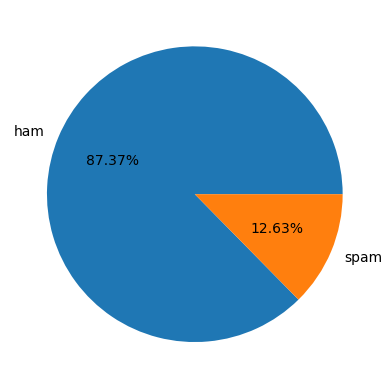

In [101]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'], autopct='%0.2f%%')

Data is imbalanced

In [102]:
import nltk

In [103]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abcsi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [104]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abcsi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [105]:
# Counting the number of characters in every text (sms)

df['num_characters']=df['text'].apply(len)
df['num_characters'].head()

0    111
1     29
2    155
3     49
4     61
Name: num_characters, dtype: int64

In [106]:
# Number of words

df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_words'].head()

0    24
1     8
2    37
3    13
4    15
Name: num_words, dtype: int64

In [107]:
# Number of sentences

df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df['num_sentences'].head()

0    2
1    2
2    2
3    1
4    1
Name: num_sentences, dtype: int64

In [108]:
df

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [109]:
df.iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [110]:
# for ham messages

df[df['target']==0].iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [111]:
# for Spam messages

df[df['target']==1].iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


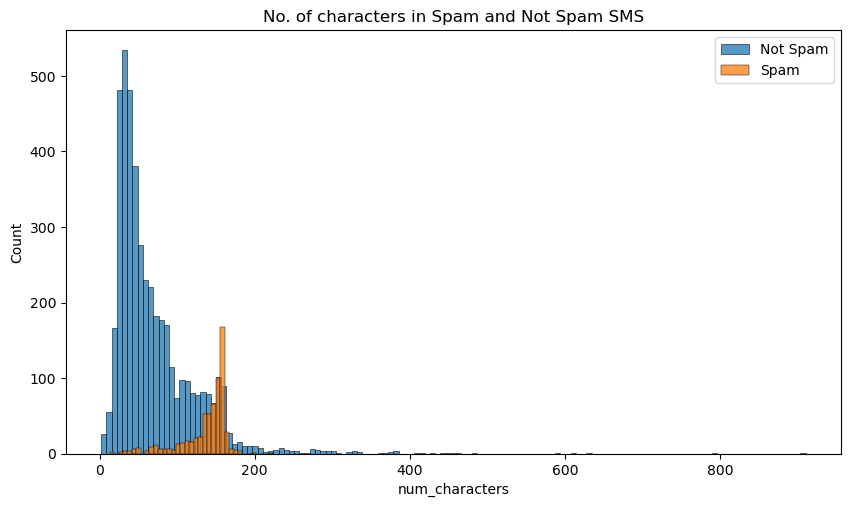

In [112]:
plt.figure(figsize=(10,5.5))
plt.title('No. of characters in Spam and Not Spam SMS')
sns.histplot(df[df['target']==0].iloc[:,2],label='Not Spam')
sns.histplot(df[df['target']==1].iloc[:,2],label='Spam')
plt.legend()
plt.show()

We can see that characters in Not Spam messages are much more than Spam messages

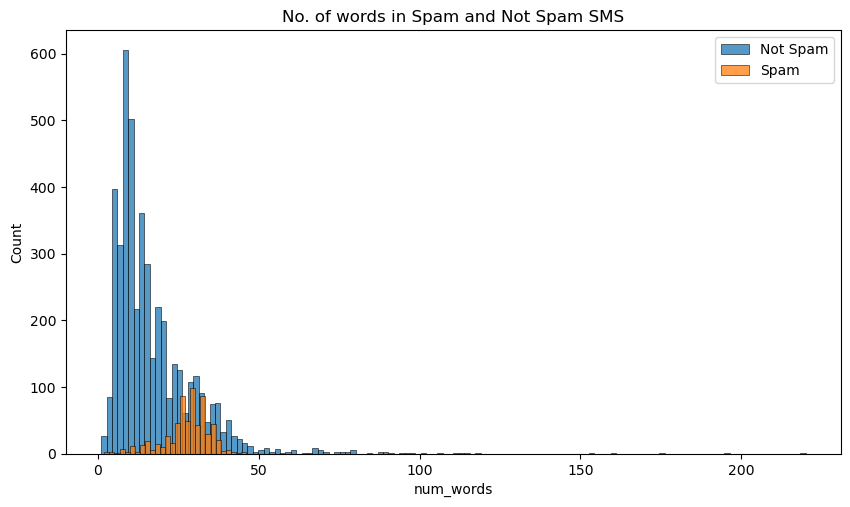

In [113]:
plt.figure(figsize=(10,5.5))
plt.title('No. of words in Spam and Not Spam SMS')
sns.histplot(df[df['target']==0].iloc[:,3],label='Not Spam')
sns.histplot(df[df['target']==1].iloc[:,3],label='Spam')
plt.legend()
plt.show()

Like we can see that Spam messages has less words 

<Axes: >

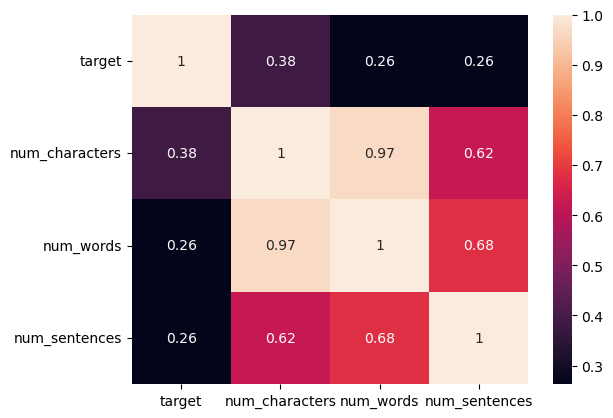

In [114]:
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True)

we can see that here is high multicollinearity. So, I will select only 1 column.


# 3. Data Preprocessing

* Lower Case
* Tokenization
* Removing Special Characters
* Removing Stop Words & Punctuations
* Stemming

In [115]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abcsi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [116]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [117]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [118]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
## Example
ps.stem('loving')

'love'

In [119]:
# Lower Case
# Tokenization
# Removing Special Characters
# Removing Stop Words & Punctuations
# Stemming


def transform_text(text):
    text=text.lower() # Converting in lower case
    # print('In Lower Case:- ', text)
    text=nltk.word_tokenize(text) # splitting text into words
    # print('Tokenized:- ', text)
    
    # Removing special characters
    L=[]
    for i in text:
        if i.isalnum():
            L.append(i)
    # print('Removed Special Characters:- ', L)

    # Removing Stop Words & Punctuations
    text=L.copy()
    L.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            L.append(i)
    # print('Removed stopwords and punctuation:- ', L)

    # Applying Stemming
    text=L.copy()
    L.clear()
    for i in text:
        L.append(ps.stem(i))

    return " ".join(L)

In [120]:
### For Example (testing the function on Random sentence)

transform_text('I am enjoying learning Machine Learning and fundamentals of A.I.. How about you?')

'enjoy learn machin learn fundament'

In [121]:
# Testing the function on data

transform_text(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [122]:
# Transforming all the text and making new column "transformed_text"

df['transformed_text']=df['text'].apply(transform_text)

In [123]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [124]:
# ! pip install WordCloud

In [125]:
from wordcloud import WordCloud

In [126]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='black')

In [127]:
# df[df['target']==1]['transformed_text'].str.cat(sep=" ")

In [128]:
#Generating WordCloud for Spam messages

spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

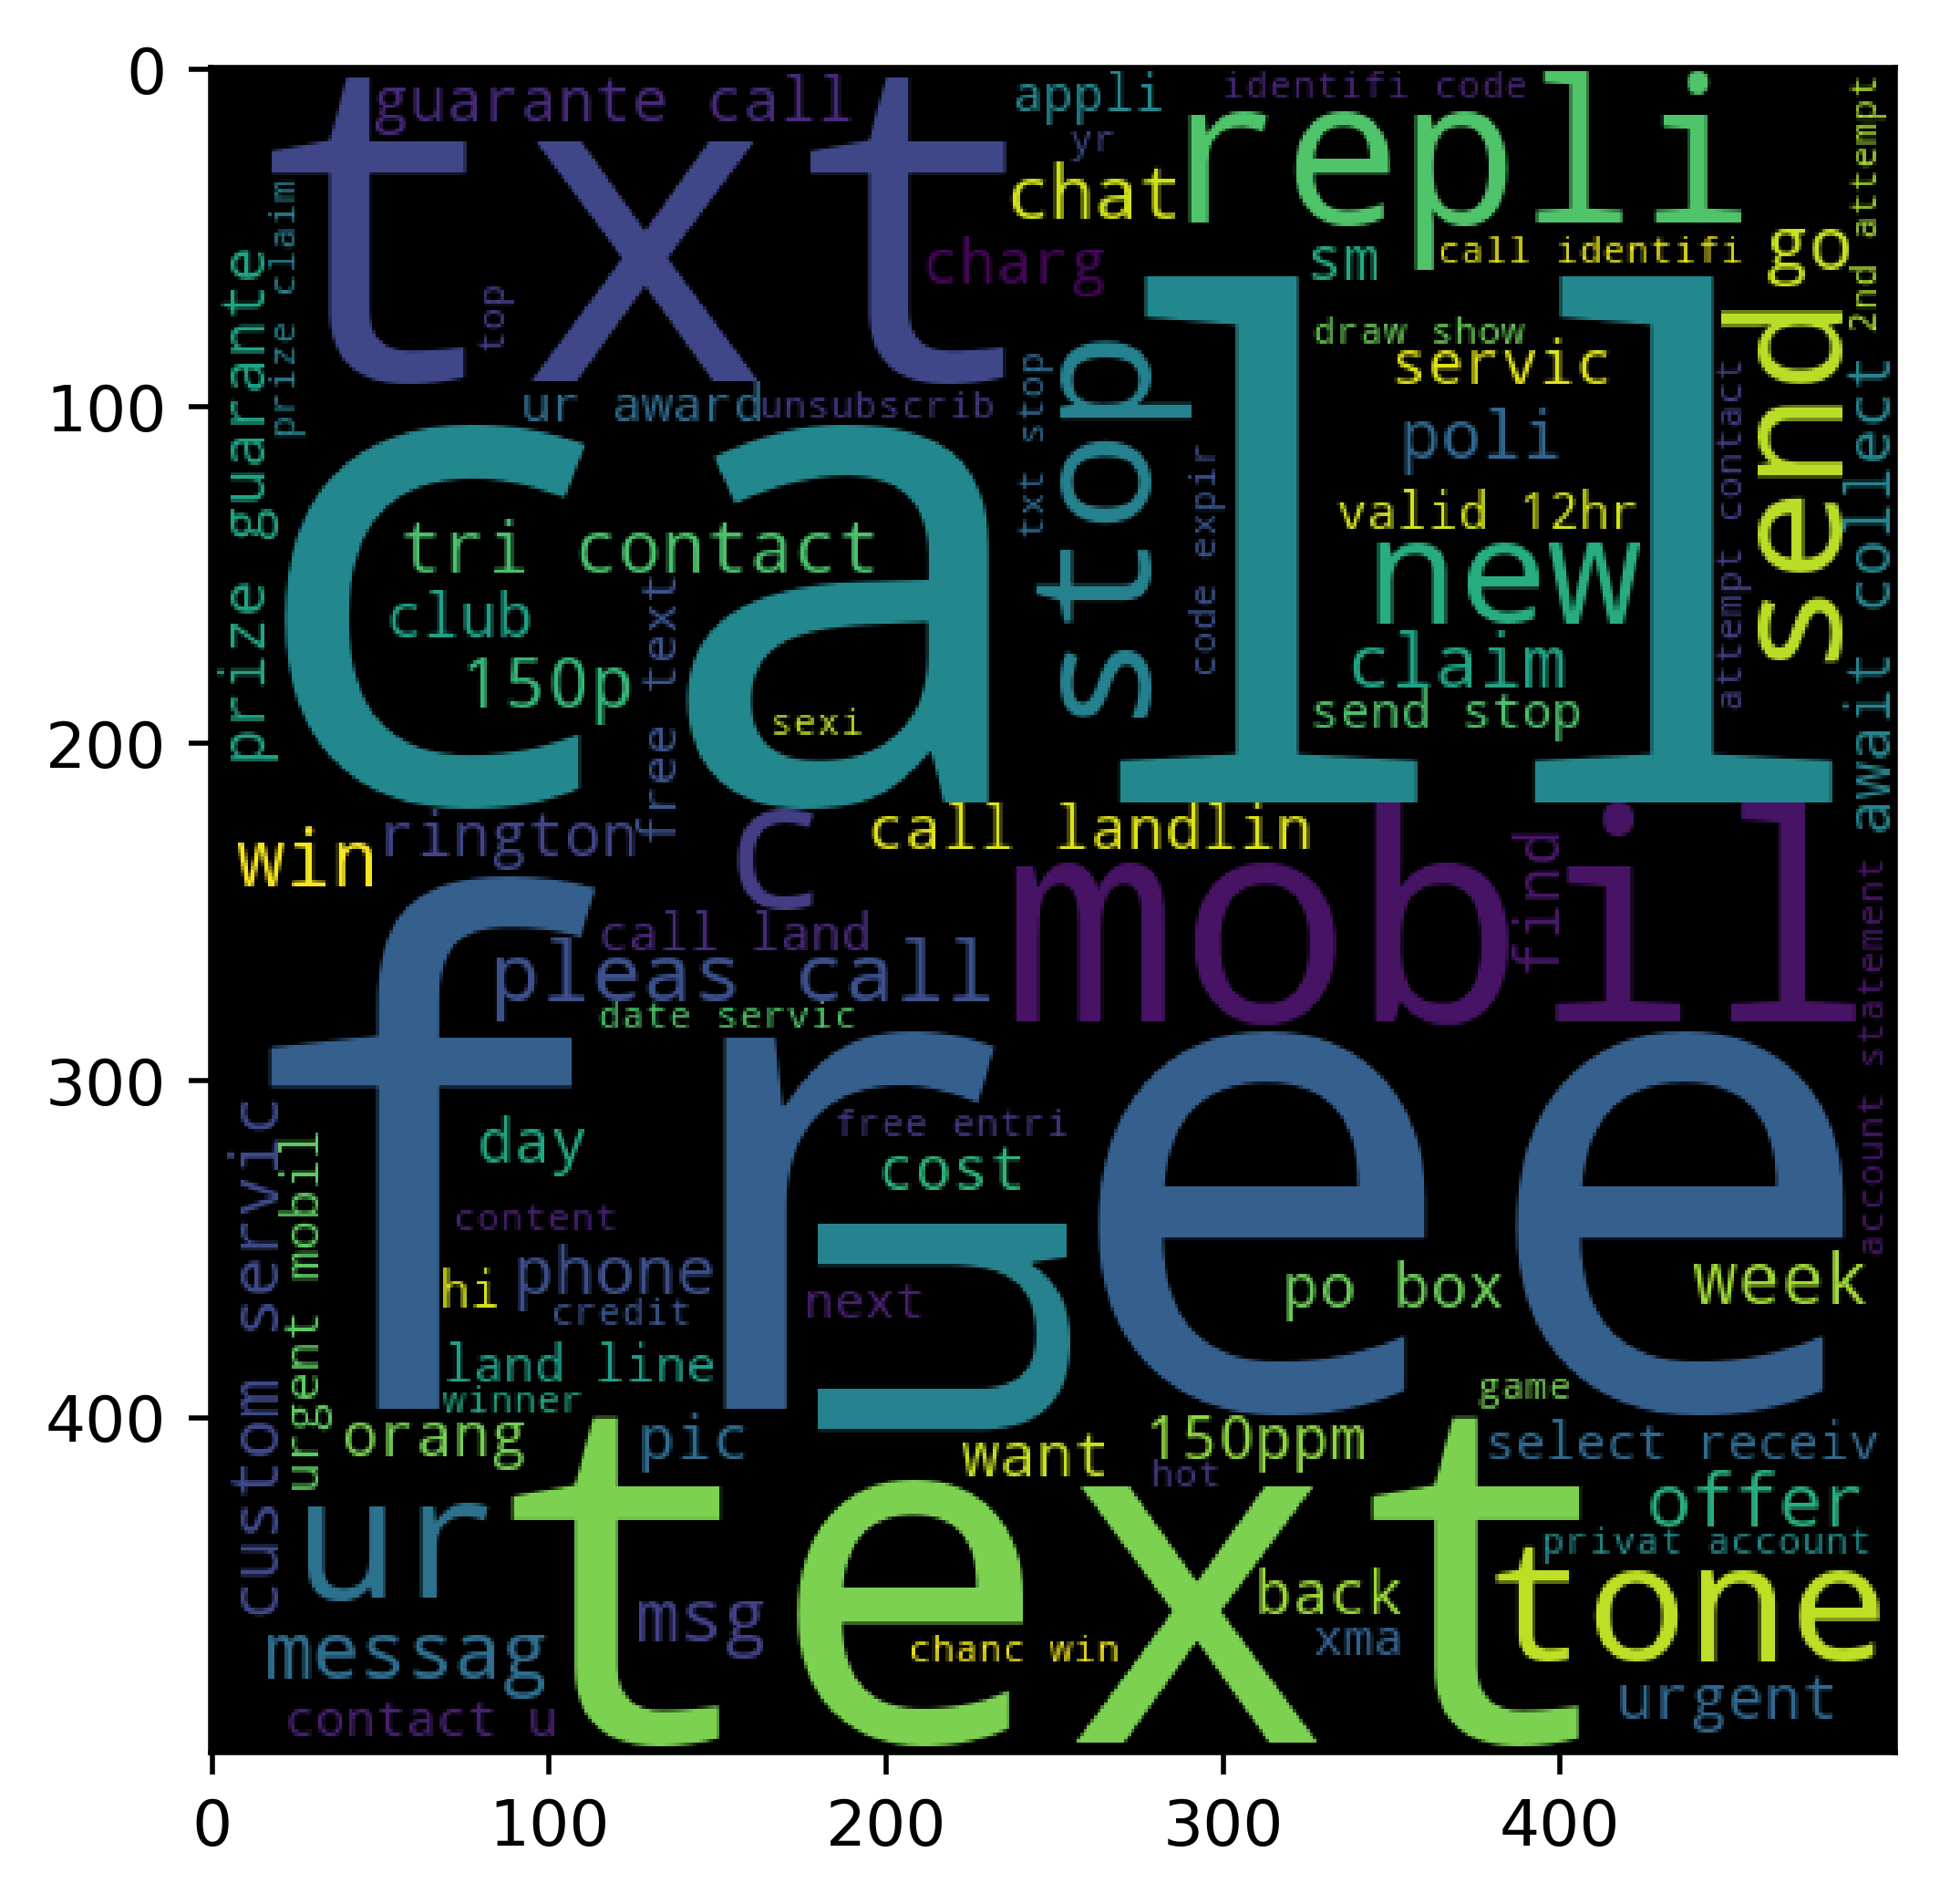

In [129]:
plt.figure(dpi=500)
plt.imshow(spam_wc)

In [130]:
# generating WordCLoud for ham messages

ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep='" "'))

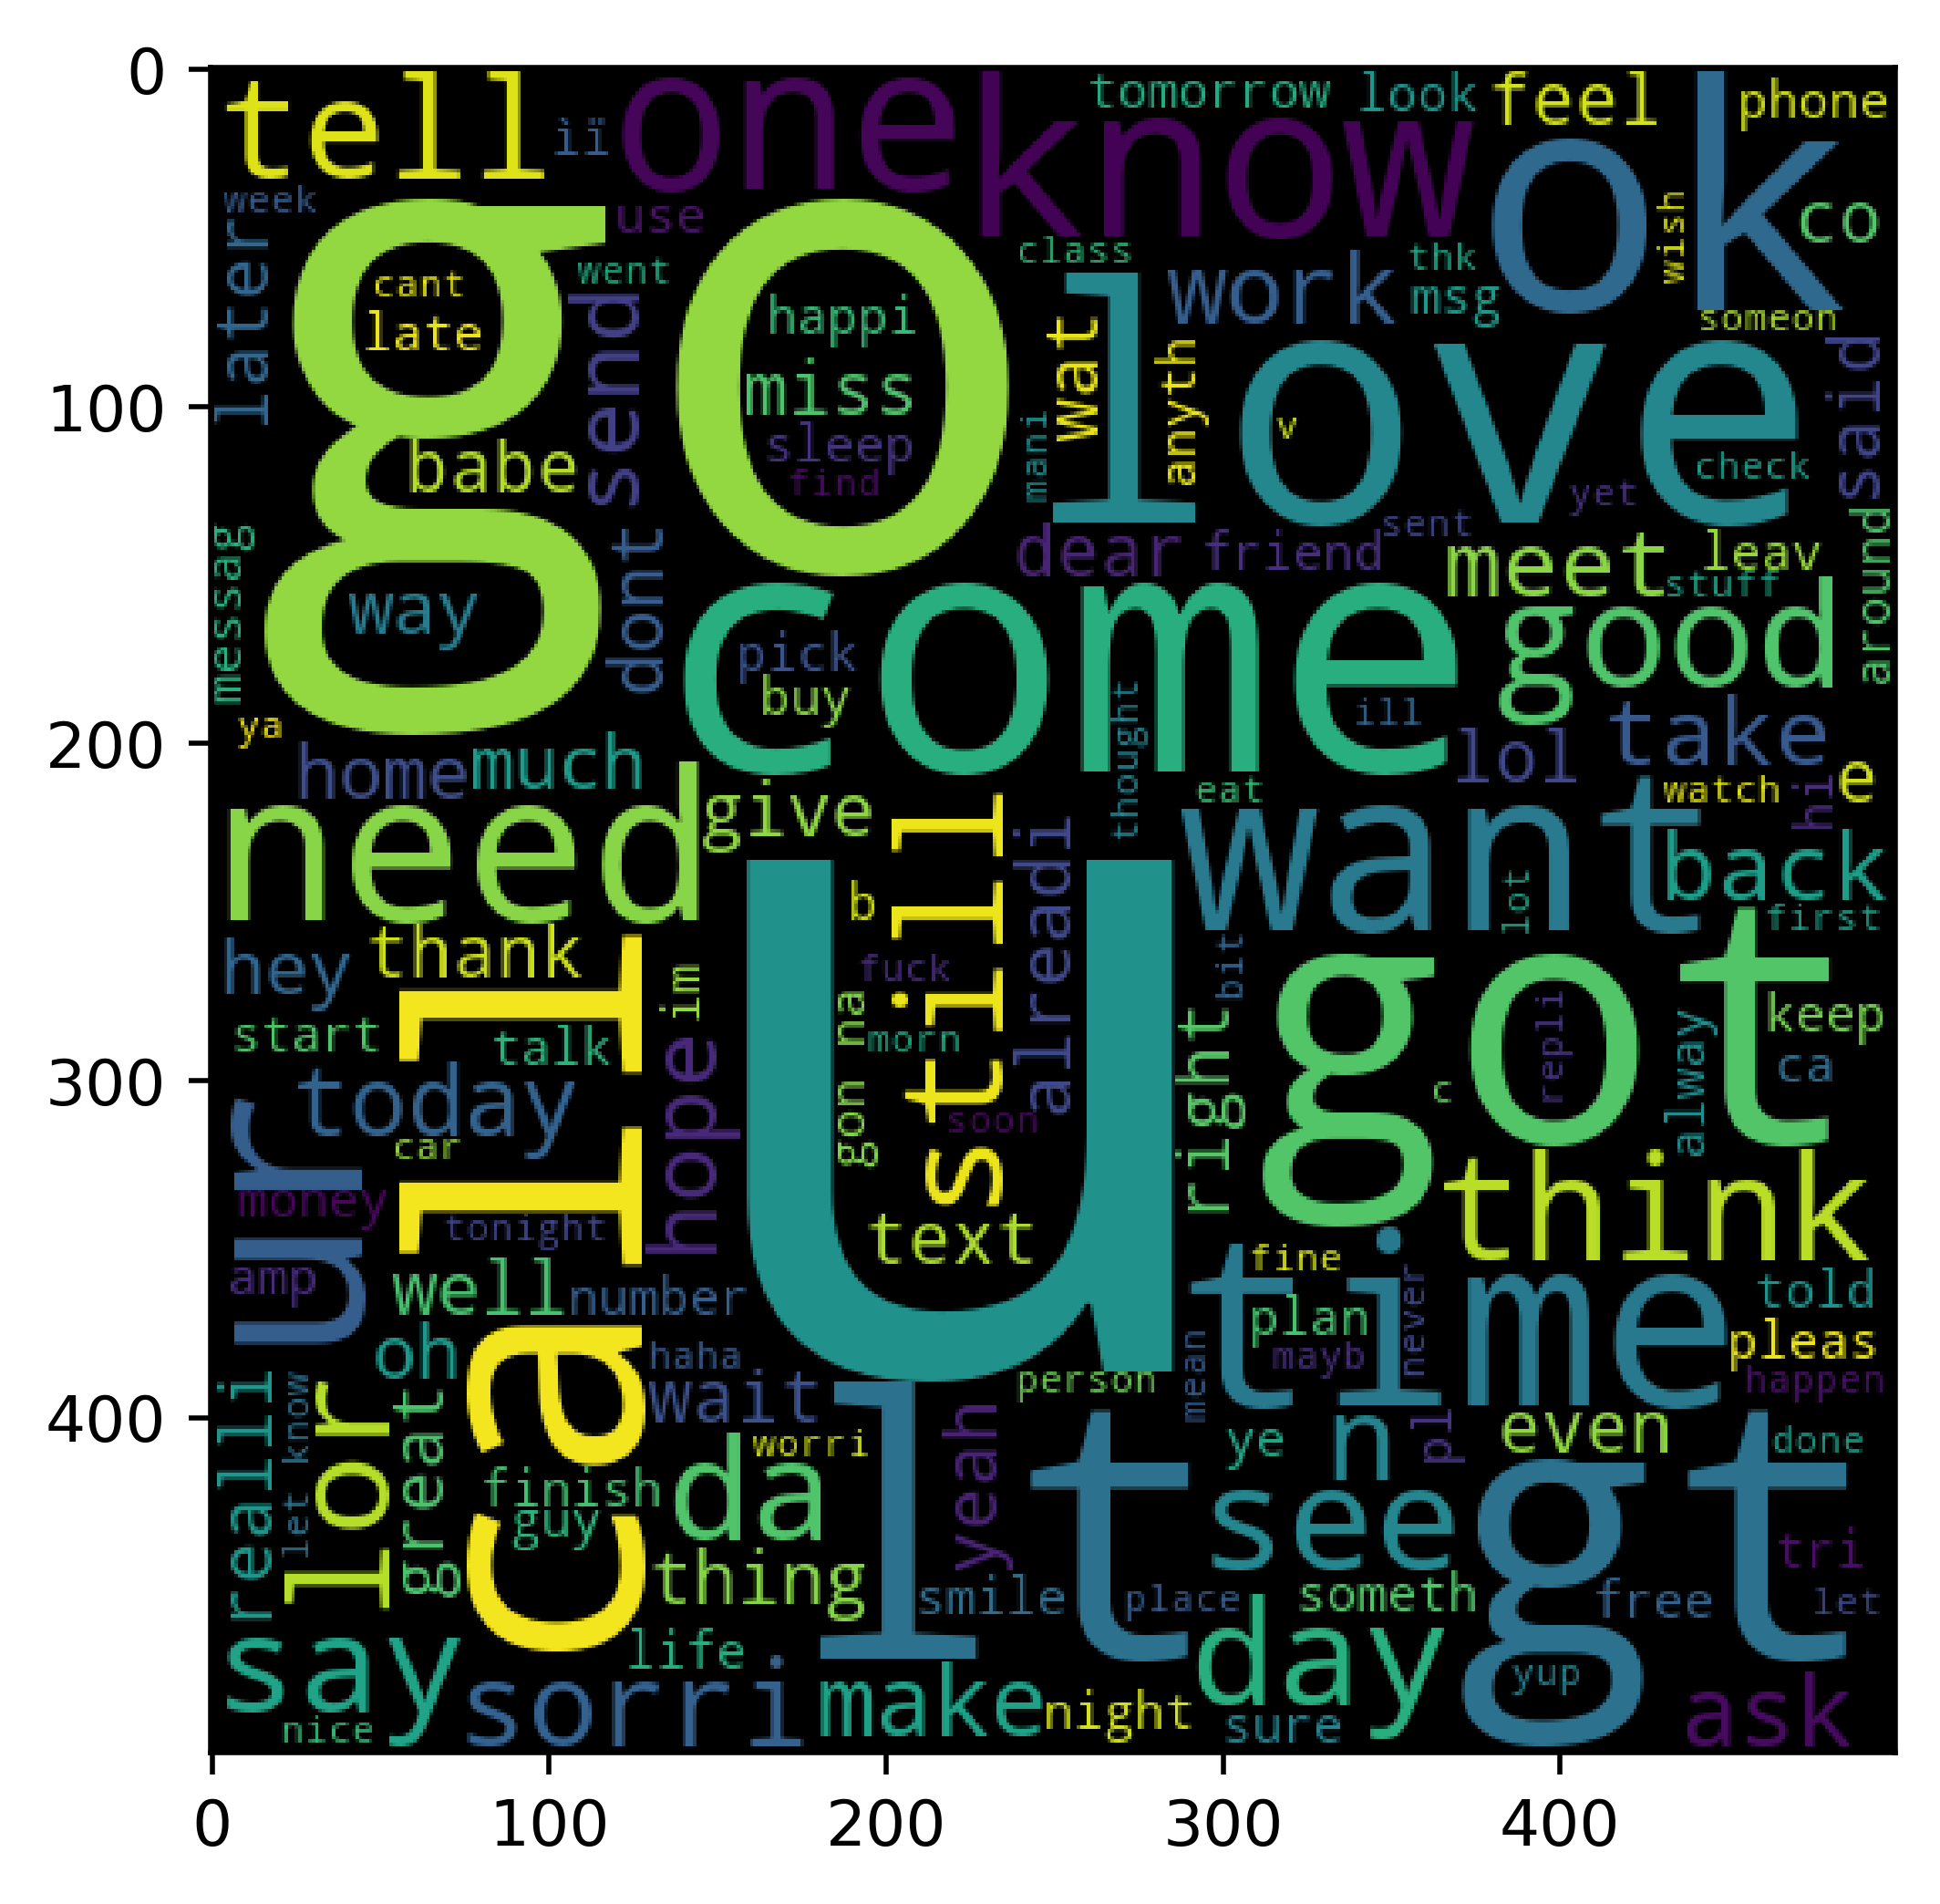

In [131]:
plt.figure(dpi=500)
plt.imshow(ham_wc)

In [132]:
# Displaying the words in Spam SMS


spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [133]:
# For counting the words
from collections import Counter

In [134]:
spam_df=pd.DataFrame(Counter(spam_corpus).most_common()).rename(columns={0:'words',1:'count'})
spam_df

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
...,...,...
2217,shit,1
2218,bailiff,1
2219,hous,1
2220,087187272008,1


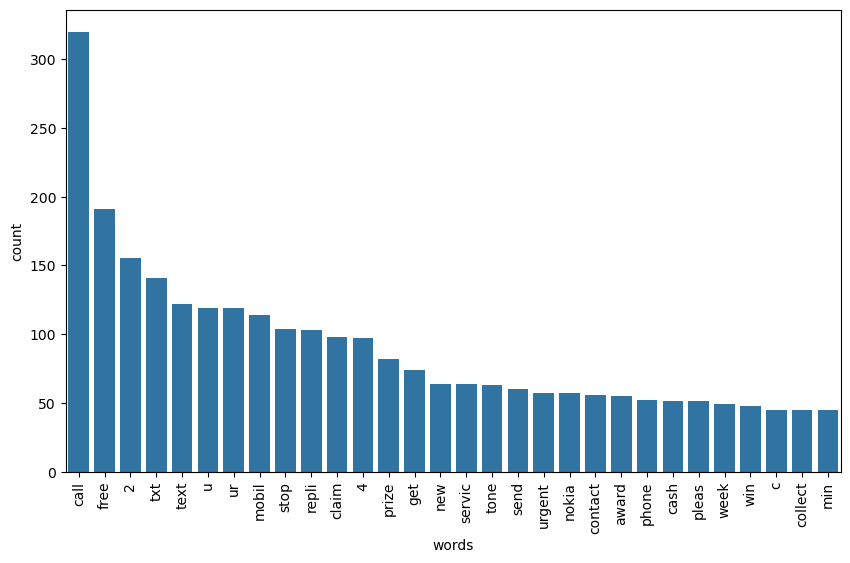

In [135]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=spam_df.head(30))
plt.xticks(rotation='vertical')
plt.show()

In [136]:
# Displaying the words in ham SMS

ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [137]:
ham_df=pd.DataFrame(Counter(ham_corpus).most_common()).rename(columns={0:'words',1:'count'})
ham_df

,words,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
...,...,...
5385,nmde,1
5386,dump,1
5387,heap,1
5388,salesman,1


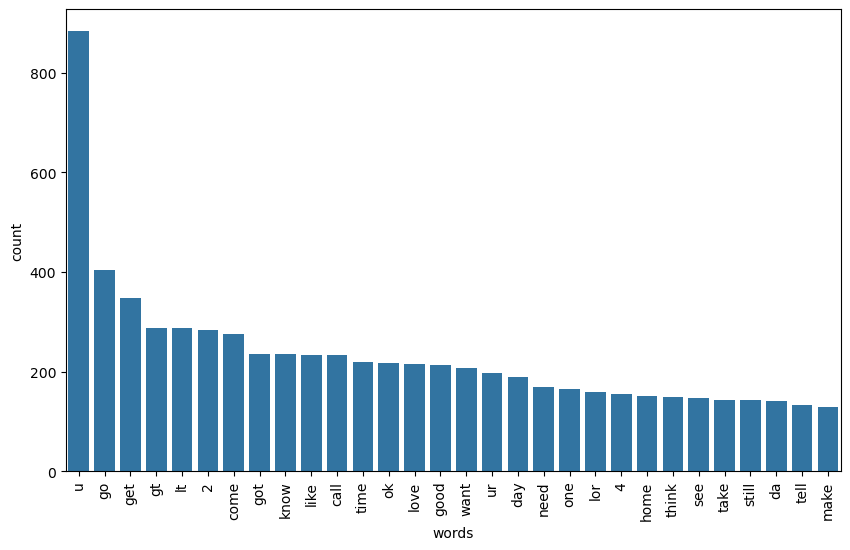

In [138]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=ham_df.head(30))
plt.xticks(rotation='vertical')
plt.show()

# 4. Feature Engineering

In [139]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [140]:
X=tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [141]:
X.shape

(5169, 3000)

In [142]:
y=df['target'].values

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [145]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [146]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [147]:
gnb.fit(x_train,y_train)
y_pred_test1=gnb.predict(x_test)
y_pred_train1=gnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test1))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train1))
print('Precision_Score',precision_score(y_train,y_pred_train1))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train1))



Testing Accuracy 0.8694390715667312
Trainning_Accuracy 0.8931076178960097
Precision_Score 0.5381400208986415
Confusion_matrix
 [[3178  442]
 [   0  515]]


In [148]:
mnb.fit(x_train,y_train)
y_pred_test2=mnb.predict(x_test)
y_pred_train2=mnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test2))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train2))
print('Precision_Score',precision_score(y_train,y_pred_train2))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train2))



Testing Accuracy 0.9709864603481625
Trainning_Accuracy 0.9789600967351875
Precision_Score 0.9953703703703703
Confusion_matrix
 [[3618    2]
 [  85  430]]


In [149]:
bnb.fit(x_train,y_train)
y_pred_test3=bnb.predict(x_test)
y_pred_train3=bnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test3))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train3))
print('Precision_Score',precision_score(y_train,y_pred_train3))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train3))



Testing Accuracy 0.9835589941972921
Trainning_Accuracy 0.9857315598548972
Precision_Score 0.9935064935064936
Confusion_matrix
 [[3617    3]
 [  56  459]]


In [150]:
svc = SVC()
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [151]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [152]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred_test = clf.predict(X_test)
    y_pred_train = clf.predict(X_train)

    accuracy_test = accuracy_score(y_test,y_pred_test)
    accuracy_train = accuracy_score(y_train,y_pred_train)
    precision = precision_score(y_test, y_pred_test, average='weighted')  # or 'macro', 'micro', etc.

    
    return accuracy_test,accuracy_train, precision

In [153]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9729206963249516, 0.9963724304715841, 0.9731694470386715)

In [154]:
accuracy_train1 = []
accuracy_test1 = []

precision_scores = []

for name,clf in clfs.items():
    
    accuracy_test,accuracy_train,precision = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Training Accuracy - ",accuracy_train)
    print("Testing Accuracy - ",accuracy_test)
    print("Precision - ",precision)
    
    accuracy_train1.append(accuracy_train)
    accuracy_test1.append(accuracy_test)

    precision_scores.append(precision)

For  SVC
Training Accuracy -  0.9963724304715841
Testing Accuracy -  0.9729206963249516
Precision -  0.9731694470386715
For  KN
Training Accuracy -  0.9257557436517533
Testing Accuracy -  0.9052224371373307
Precision -  0.9145667038984391
For  NB
Training Accuracy -  0.9789600967351875
Testing Accuracy -  0.9709864603481625
Precision -  0.971926423835803
For  DT
Training Accuracy -  0.9492140266021766
Testing Accuracy -  0.9303675048355899
Precision -  0.9262341353453226
For  LR
Training Accuracy -  0.965659008464329
Testing Accuracy -  0.9564796905222437
Precision -  0.9574817949660491
For  RF
Training Accuracy -  0.999758162031439
Testing Accuracy -  0.9758220502901354
Precision -  0.9759842777546205
For  AdaBoost
Training Accuracy -  0.9717049576783555
Testing Accuracy -  0.960348162475822
Precision -  0.9595027601236827
For  BgC
Training Accuracy -  0.9990326481257558
Testing Accuracy -  0.9584139264990329
Precision -  0.957516941029288
For  ETC
Training Accuracy -  0.9997581620314

In [155]:
performance_df =pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_train':accuracy_train1,'Accuracy_test':accuracy_test1,'Precision':precision_scores})
performance_df.sort_values(by='Accuracy_test',ascending=False)

,Algorithm,Accuracy_train,Accuracy_test,Precision
5,RF,0.999758,0.975822,0.975984
8,ETC,0.999758,0.974855,0.974849
0,SVC,0.996372,0.972921,0.973169
2,NB,0.978960,0.970986,0.971926
10,xgb,0.984039,0.967118,0.966666
6,AdaBoost,0.971705,0.960348,0.959503
7,BgC,0.999033,0.958414,0.957517
4,LR,0.965659,0.956480,0.957482
9,GBDT,0.967110,0.946809,0.945657
3,DT,0.949214,0.930368,0.926234


In [156]:
performance_df.sort_values('Precision',ascending=False)

,Algorithm,Accuracy_train,Accuracy_test,Precision
5,RF,0.999758,0.975822,0.975984
8,ETC,0.999758,0.974855,0.974849
0,SVC,0.996372,0.972921,0.973169
2,NB,0.978960,0.970986,0.971926
10,xgb,0.984039,0.967118,0.966666
6,AdaBoost,0.971705,0.960348,0.959503
7,BgC,0.999033,0.958414,0.957517
4,LR,0.965659,0.956480,0.957482
9,GBDT,0.967110,0.946809,0.945657
3,DT,0.949214,0.930368,0.926234
